# Simulation CSV Plots

Set `CSV_PATH` below if you want a specific run. Leave it as `None` to use the newest `data/run_*.csv` file.

In [1]:
# Uncomment this if your notebook kernel does not have the plotting packages:
# %pip install pandas matplotlib

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "misc":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Set this to a specific file if needed, for example:
# CSV_PATH = PROJECT_ROOT / "data" / "run_2026-06-07T19-54-22.csv"
CSV_PATH = None

if CSV_PATH is None:
    run_files = sorted((PROJECT_ROOT / "data").glob("run_*.csv"), key=lambda path: path.stat().st_mtime)
    if not run_files:
        raise FileNotFoundError("No data/run_*.csv files found")
    CSV_PATH = run_files[-1]

df = pd.read_csv(CSV_PATH)
df.head()

,epoch,year,population,food,bushes,avg_speed,avg_vision,avg_reproduction,max_generation,oldest_age,oldest_bush_age,births,deaths,food_eaten,seeds_found,seeds_planted,seeds_held
0,1,0.05,20,13,15,150.0,150.0,400.0,0,0.05,0.05,0,0,2,1,0,1
1,2,0.10,20,5,15,150.0,150.0,400.0,0,0.10,0.10,0,0,8,4,0,5
2,3,0.15,20,2,15,150.0,150.0,400.0,0,0.15,0.15,0,0,3,2,0,7
3,4,0.21,20,1,16,150.0,150.0,400.0,0,0.20,0.20,0,0,2,1,1,7
4,5,0.26,20,2,17,150.0,150.0,400.0,0,0.26,0.26,0,0,2,1,1,7


In [2]:
print(f"Loaded: {CSV_PATH}")
print(f"Rows: {len(df)}")
df.describe().T

Loaded: /Users/naresh/evolution/data/run_2026-06-08T00-21-51.csv
Rows: 453


,count,mean,std,min,25%,50%,75%,max
epoch,453.0,227.000000,130.914094,1.00,114.00,227.00,340.00,453.00
year,453.0,11.561302,6.620777,0.05,5.89,11.58,17.23,23.07
population,453.0,122.355408,332.790394,9.00,12.00,19.00,27.00,2223.00
food,453.0,17.024283,7.277486,1.00,12.00,17.00,22.00,40.00
bushes,453.0,259.245033,604.439267,15.00,48.00,80.00,119.00,4218.00
avg_speed,453.0,151.719801,2.524274,148.44,149.60,150.36,153.77,158.56
avg_vision,453.0,153.259073,2.112848,150.00,151.69,153.29,155.13,157.74
avg_reproduction,453.0,398.001479,1.144750,395.58,397.25,397.85,398.29,400.37
max_generation,453.0,4.037528,3.693561,0.00,2.00,3.00,5.00,15.00
oldest_age,453.0,10.066799,5.175586,0.05,5.89,10.77,13.68,19.32


In [3]:
def plot_columns(title, columns, normalize=False):
    missing = [column for column in columns if column not in df.columns]
    if missing:
        print(f"Skipping missing columns: {missing}")

    columns = [column for column in columns if column in df.columns]
    if not columns:
        raise KeyError("None of the requested columns exist in this CSV")

    plot_df = df[["epoch", *columns]].copy()

    if normalize:
        for column in columns:
            min_value = plot_df[column].min()
            max_value = plot_df[column].max()
            if max_value != min_value:
                plot_df[column] = (plot_df[column] - min_value) / (max_value - min_value)

    fig, ax = plt.subplots(figsize=(12, 5.5))

    for column in columns:
        ax.plot(plot_df["epoch"], plot_df[column], linewidth=2, label=column)

    ax.set_title(title)
    ax.set_xlabel("epoch")
    ax.set_ylabel("normalized value" if normalize else "value")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    plt.show()

## Plot 1: Population Dynamics

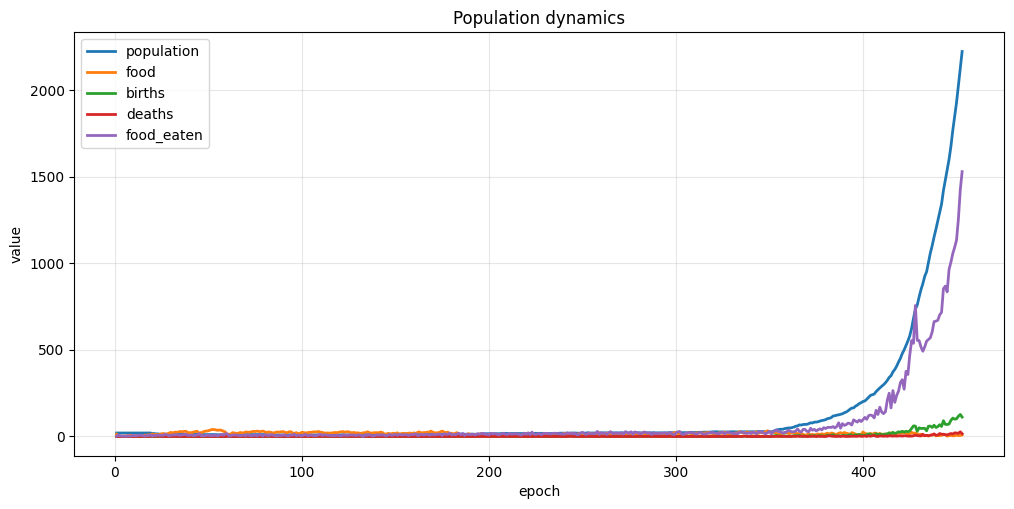

In [4]:
plot_columns(
    "Population dynamics",
    ["population", "food", "births", "deaths", "food_eaten"],
    normalize=False,
)

## Plot 2: Average Traits

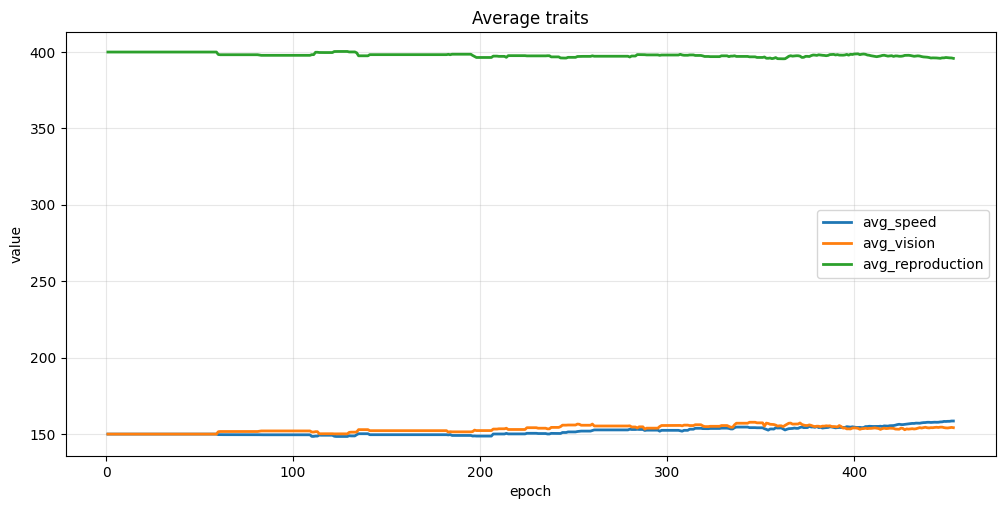

In [5]:
plot_columns(
    "Average traits",
    ["avg_speed", "avg_vision", "avg_reproduction"],
    normalize=False,
)

## Plot 3: Age And Generation

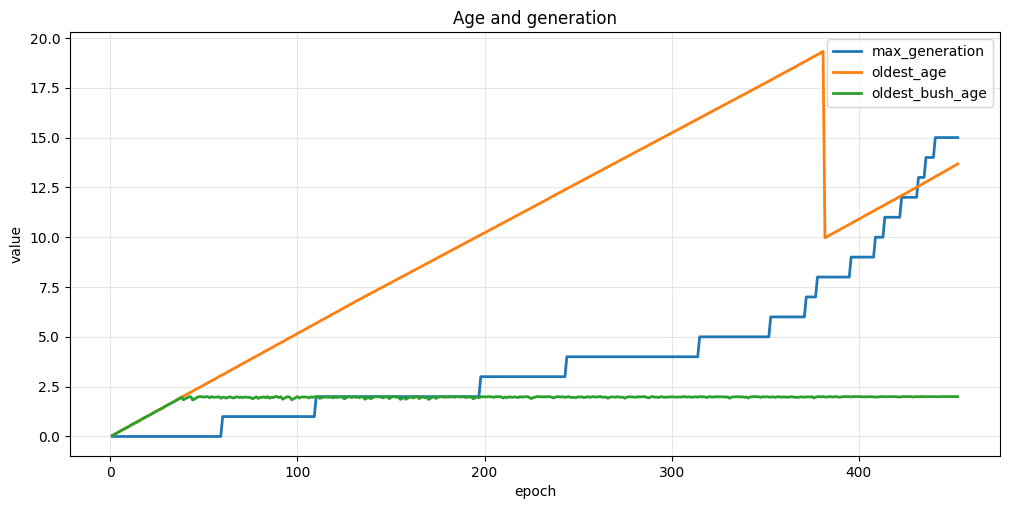

In [6]:
plot_columns(
    "Age and generation",
    ["max_generation", "oldest_age", "oldest_bush_age"],
    normalize=False,
)